## Imports + configuration

In [2]:
%pip install tqdm


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
import os
import glob
import math
import random
import numpy as np
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader, random_split

from scipy.sparse import csr_matrix, eye
from scipy.sparse.linalg import spsolve

In [10]:
# ============================================================
# Configuration
# ============================================================

DATASET_DIR = "dataset"
SR_CACHE_DIR = "dataset_sr_gamma099_8x8"
IMAGE_SIZE = 64
BATCH_SIZE = 32
NUM_EPOCHS = 100
LEARNING_RATE = 2e-4
TIMESTEPS = 1000
LATENT_CHANNELS = 16
BASE_CHANNELS = 64
TRAIN_RATIO = 0.9
NUM_WORKERS = 0
SEED = 42
PATH_WEIGHT = 5.0

SR_GAMMA = 0.99
SR_REGIONS_PER_AXIS = 8
SR_CHANNELS = SR_REGIONS_PER_AXIS ** 2
MAP_CHANNELS = 3
DIRECTIONAL_CHANNELS = 4
ENCODER_INPUT_CHANNELS = MAP_CHANNELS + SR_CHANNELS

MAP_BRANCH_CHANNELS = 16
DIRECTIONAL_BRANCH_CHANNELS = 16
SR_BRANCH_CHANNELS = 32

CHECKPOINT_DIR = (
    "checkpoints_cognitive_SR64_gamma099_"
    "directional-hybrid_x0+path-weighted"
)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", DEVICE)
print("SR gamma:", SR_GAMMA)
print("SR regions:", SR_REGIONS_PER_AXIS, "x", SR_REGIONS_PER_AXIS)
print("SR channels:", SR_CHANNELS)
print("Directional channels:", DIRECTIONAL_CHANNELS)
print("Dataset conditioning channels:", ENCODER_INPUT_CHANNELS)

Device: cuda
SR gamma: 0.99
SR regions: 8 x 8
SR channels: 64
Directional channels: 4
Dataset conditioning channels: 67


In [11]:
# ============================================================
# Reproducibility
# ============================================================

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

os.makedirs(
    CHECKPOINT_DIR,
    exist_ok=True
)

## Successor Representation cognitive map

In [12]:
# ============================================================
# Successor Representation utilities
# ============================================================

def build_random_walk_transition_csr(obstacle_map):
    """
    Build sparse random-walk transition matrix P.

    Parameters
    ----------
    obstacle_map : np.ndarray
        Shape [64, 64]

        Dataset convention:
            1 = obstacle
            0 = free

    Returns
    -------
    P : scipy.sparse.csr_matrix
        Shape [4096, 4096]

        For each free cell:
            - inspect legal 4-neighbour free cells
            - distribute transition probability uniformly

        Obstacles and isolated free cells use a self-loop.

    Important
    ---------
    This uses ONLY obstacle information.

    It does NOT use:
        - start
        - goal
        - A* path
        - shortest-path policy
    """

    obstacle_map = np.asarray(
        obstacle_map,
        dtype=np.float32,
    )

    if obstacle_map.ndim != 2:
        raise ValueError(
            f"Expected obstacle map [H,W], "
            f"got {obstacle_map.shape}"
        )

    H, W = obstacle_map.shape

    if (H, W) != (
        IMAGE_SIZE,
        IMAGE_SIZE,
    ):
        raise ValueError(
            f"Expected "
            f"{(IMAGE_SIZE, IMAGE_SIZE)}, "
            f"got {(H, W)}"
        )

    num_states = H * W

    rows = []
    cols = []
    data = []

    directions = [
        (-1, 0),   # up
        (1, 0),    # down
        (0, -1),   # left
        (0, 1),    # right
    ]

    for r in range(H):

        for c in range(W):

            state = (
                r * W
                +
                c
            )

            # ====================================
            # Obstacle state
            # ====================================
            #
            # Use a self-loop so every row of P
            # remains stochastic.
            #
            # Obstacle Phi/Psi values are zeroed
            # before the representation is used.
            # ====================================

            if obstacle_map[r, c] > 0.5:

                rows.append(state)
                cols.append(state)
                data.append(1.0)

                continue

            neighbours = []

            for dr, dc in directions:

                nr = r + dr
                nc = c + dc

                if not (
                    0 <= nr < H
                    and
                    0 <= nc < W
                ):
                    continue

                if obstacle_map[nr, nc] > 0.5:
                    continue

                neighbour_state = (
                    nr * W
                    +
                    nc
                )

                neighbours.append(
                    neighbour_state
                )

            # ====================================
            # Isolated free cell
            # ====================================

            if len(neighbours) == 0:

                rows.append(state)
                cols.append(state)
                data.append(1.0)

                continue

            # ====================================
            # Uniform random-walk policy
            # ====================================

            probability = (
                1.0
                /
                len(neighbours)
            )

            for neighbour_state in neighbours:

                rows.append(state)
                cols.append(neighbour_state)
                data.append(probability)

    P = csr_matrix(
        (
            np.asarray(
                data,
                dtype=np.float32,
            ),
            (
                np.asarray(
                    rows,
                    dtype=np.int32,
                ),
                np.asarray(
                    cols,
                    dtype=np.int32,
                ),
            ),
        ),
        shape=(
            num_states,
            num_states,
        ),
        dtype=np.float32,
    )

    return P


def build_region_phi(
    obstacle_map,
    regions_per_axis=SR_REGIONS_PER_AXIS,
):
    """
    Build fixed spatial-region features Phi.

    This version divides 64x64 into:

        8 x 8 = 64 regions

    Each region is:

        8 x 8 cells

    Returns
    -------
    Phi : np.ndarray
        Shape [4096, 64]

        Phi[state, region] = 1
        if a FREE state belongs to that region.

        Obstacle rows are all zero.
    """

    obstacle_map = np.asarray(
        obstacle_map,
        dtype=np.float32,
    )

    H, W = obstacle_map.shape

    if (
        H % regions_per_axis != 0
        or
        W % regions_per_axis != 0
    ):
        raise ValueError(
            "Grid size must be divisible "
            "by regions_per_axis."
        )

    num_states = H * W

    num_regions = (
        regions_per_axis
        **
        2
    )

    Phi = np.zeros(
        (
            num_states,
            num_regions,
        ),
        dtype=np.float32,
    )

    region_h = (
        H
        //
        regions_per_axis
    )

    region_w = (
        W
        //
        regions_per_axis
    )

    for r in range(H):

        for c in range(W):

            # Obstacles have no region feature.
            if obstacle_map[r, c] > 0.5:
                continue

            state = (
                r * W
                +
                c
            )

            region_row = (
                r
                //
                region_h
            )

            region_col = (
                c
                //
                region_w
            )

            region_id = (
                region_row
                *
                regions_per_axis
                +
                region_col
            )

            Phi[
                state,
                region_id
            ] = 1.0

    return Phi


def compute_successor_features_sparse_solve(
    P,
    Phi,
    gamma=SR_GAMMA,
    normalize=True,
):
    """
    Compute successor features by solving:

        (I - gamma P) Psi = Phi

    Therefore:

        Psi = (I - gamma P)^(-1) Phi

    but IMPORTANTLY:

        we do NOT explicitly compute the inverse
        and we do NOT build a dense 4096x4096 SR.

    Instead scipy solves the sparse linear system.

    Shapes
    ------

        P:
            [4096, 4096] sparse

        Phi:
            [4096, 64] dense

        Psi:
            [4096, 64] dense

    Why use this version?
    ---------------------

    With gamma = 0.99, fixed-point iteration

        Psi_(t+1) = Phi + gamma P Psi_t

    can require many iterations.

    Sparse linear solving is therefore a cleaner
    cache-generation method for this long-horizon
    experiment.
    """

    if not (
        0.0 <= gamma < 1.0
    ):
        raise ValueError(
            "gamma must satisfy "
            "0 <= gamma < 1."
        )

    num_states = P.shape[0]

    # ========================================
    # A = I - gamma P
    # ========================================

    I = eye(
        num_states,
        format="csr",
        dtype=np.float64,
    )

    A = (
        I
        -
        gamma
        *
        P.astype(np.float64)
    )

    # spsolve works efficiently with CSC
    # for the sparse coefficient matrix.
    A = A.tocsc()

    # ========================================
    # Solve all 64 RHS columns.
    #
    # Result:
    #     [4096, 64]
    # ========================================

    Psi = spsolve(
        A,
        Phi.astype(np.float64),
    )

    # scipy may return a matrix-like object;
    # force a normal dense ndarray.
    Psi = np.asarray(
        Psi,
        dtype=np.float64,
    )

    # ========================================
    # Normalize SR magnitude
    #
    # For row-stochastic P:
    #
    #     sum_k Psi[s,k]
    #       ~= 1 / (1-gamma)
    #
    # so multiplying by (1-gamma)
    # makes free-state channel sums ~= 1.
    # ========================================

    if normalize:

        Psi = (
            (1.0 - gamma)
            *
            Psi
        )

    return Psi.astype(
        np.float32
    )


def build_sr_cognitive_map(
    obstacle_map,
    gamma=SR_GAMMA,
    regions_per_axis=SR_REGIONS_PER_AXIS,
    normalize=True,
    return_intermediate=False,
):
    """
    Full conversion:

        obstacle map
            [64,64]

        ->
        sparse random-walk P
            [4096,4096]

        ->
        Phi
            [4096,64]

        ->
        sparse solve
        (I - gamma P) Psi = Phi

        ->
        Psi
            [4096,64]

        ->
        SR cognitive map
            [64,64,64]
            channel-first: [64,64,64]
    """

    obstacle_map = np.asarray(
        obstacle_map,
        dtype=np.float32,
    )

    H, W = obstacle_map.shape

    P = build_random_walk_transition_csr(
        obstacle_map
    )

    Phi = build_region_phi(
        obstacle_map,
        regions_per_axis=regions_per_axis,
    )

    Psi = compute_successor_features_sparse_solve(
        P=P,
        Phi=Phi,
        gamma=gamma,
        normalize=normalize,
    )

    num_regions = (
        regions_per_axis
        **
        2
    )

    # ========================================
    # [4096,64]
    # ->
    # [64,64,64] as H,W,C
    # ->
    # [64,64,64] as C,H,W
    #
    # Numerically the dimensions happen to
    # all equal 64, so keep this transpose
    # explicit to preserve semantics.
    # ========================================

    cognitive_map = (
        Psi
        .reshape(
            H,
            W,
            num_regions,
        )
        .transpose(
            2,
            0,
            1,
        )
        .copy()
    )

    # Explicitly remove obstacle values.
    obstacle_mask = (
        obstacle_map
        >
        0.5
    )

    cognitive_map[
        :,
        obstacle_mask
    ] = 0.0

    cognitive_map = (
        cognitive_map
        .astype(
            np.float32
        )
    )

    if return_intermediate:

        return {
            "cognitive_map":
                cognitive_map,

            "P":
                P,

            "Phi":
                Phi,

            "Psi":
                Psi,
        }

    return cognitive_map


# ============================================================
# SR cache
# ============================================================

def precompute_sr_cache(
    dataset_dir,
    cache_dir,
    gamma=SR_GAMMA,
    regions_per_axis=SR_REGIONS_PER_AXIS,
    overwrite=False,
):
    """
    Precompute one SR map per dataset sample.

    Input:
        dataset/pair_XXXXX.npz

    Output:
        cache_dir/pair_XXXXX.npy

    Cached shape:
        [64,64,64]

    Existing VALID cache files are reused when
    overwrite=False.
    """

    os.makedirs(
        cache_dir,
        exist_ok=True,
    )

    files = sorted(
        glob.glob(
            os.path.join(
                dataset_dir,
                "pair_*.npz",
            )
        )
    )

    if len(files) == 0:

        raise RuntimeError(
            f"No pair_*.npz files found "
            f"in {dataset_dir}"
        )

    expected_shape = (
        regions_per_axis ** 2,
        IMAGE_SIZE,
        IMAGE_SIZE,
    )

    computed = 0
    skipped = 0

    for filepath in tqdm(
        files,
        desc="Precomputing SR64 cache",
    ):

        basename = (
            os.path.splitext(
                os.path.basename(
                    filepath
                )
            )[0]
        )

        cache_path = (
            os.path.join(
                cache_dir,
                basename
                +
                ".npy",
            )
        )

        # ====================================
        # Reuse valid cache
        # ====================================

        if (
            os.path.exists(
                cache_path
            )
            and
            not overwrite
        ):

            try:

                cached = np.load(
                    cache_path,
                    mmap_mode="r",
                )

                if (
                    cached.shape
                    ==
                    expected_shape
                    and
                    cached.dtype
                    ==
                    np.float32
                ):
                    skipped += 1
                    continue

            except Exception:
                pass

        # ====================================
        # Load original sample
        # ====================================

        with np.load(
            filepath
        ) as data:

            grid_map = (
                data["map"]
                .astype(
                    np.float32
                )
            )

        expected_map_shape = (
            3,
            IMAGE_SIZE,
            IMAGE_SIZE,
        )

        if (
            grid_map.shape
            !=
            expected_map_shape
        ):

            raise ValueError(
                f"{filepath}: "
                f"expected map shape "
                f"{expected_map_shape}, "
                f"got {grid_map.shape}"
            )

        obstacle_map = (
            grid_map[0]
        )

        sr_map = (
            build_sr_cognitive_map(
                obstacle_map=obstacle_map,
                gamma=gamma,
                regions_per_axis=regions_per_axis,
                normalize=True,
            )
        )

        # ====================================
        # Atomic-ish cache write:
        # write temp file then replace target
        # ====================================

        tmp_path = (
            cache_path
            +
            ".tmp.npy"
        )

        np.save(
            tmp_path,
            sr_map.astype(
                np.float32
            ),
        )

        os.replace(
            tmp_path,
            cache_path,
        )

        computed += 1

    print()
    print("SR cache ready.")
    print("Computed:", computed)
    print("Skipped existing:", skipped)
    print("Cache directory:", cache_dir)


def verify_sr_cache_sample(
    dataset_dir,
    cache_dir,
    sample_index=0,
):
    """
    Sanity-check one cached SR sample.
    """

    npz_path = os.path.join(
        dataset_dir,
        f"pair_{sample_index:05d}.npz",
    )

    npy_path = os.path.join(
        cache_dir,
        f"pair_{sample_index:05d}.npy",
    )

    with np.load(
        npz_path
    ) as data:

        grid_map = (
            data["map"]
            .astype(
                np.float32
            )
        )

    sr_map = np.load(
        npy_path
    ).astype(
        np.float32
    )

    obstacle = (
        grid_map[0]
        >
        0.5
    )

    free = (
        ~obstacle
    )

    sr_sum = (
        sr_map.sum(
            axis=0
        )
    )

    print(
        "Original map:",
        grid_map.shape,
    )

    print(
        "SR map:",
        sr_map.shape,
    )

    print(
        "SR min/max:",
        float(sr_map.min()),
        float(sr_map.max()),
    )

    print(
        "Free-cell SR channel-sum min/max:",
        float(
            sr_sum[free].min()
        ),
        float(
            sr_sum[free].max()
        ),
    )

    if obstacle.any():

        print(
            "Obstacle SR absolute max:",
            float(
                np.abs(
                    sr_map[
                        :,
                        obstacle
                    ]
                ).max()
            ),
        )

In [13]:
# ============================================================
# Build / reuse SR64 gamma=0.99 cache
# ============================================================

precompute_sr_cache(
    dataset_dir=DATASET_DIR,
    cache_dir=SR_CACHE_DIR,
    gamma=SR_GAMMA,
    regions_per_axis=SR_REGIONS_PER_AXIS,
    overwrite=False,
)

verify_sr_cache_sample(
    dataset_dir=DATASET_DIR,
    cache_dir=SR_CACHE_DIR,
    sample_index=0,
)

Precomputing SR64 cache:   0%|          | 0/10000 [00:00<?, ?it/s]


SR cache ready.
Computed: 0
Skipped existing: 10000
Cache directory: dataset_sr_gamma099_8x8
Original map: (3, 64, 64)
SR map: (64, 64, 64)
SR min/max: 0.0 0.6739731431007385
Free-cell SR channel-sum min/max: 1.0000017881393433 1.0000029802322388
Obstacle SR absolute max: 0.0


## Dataset loader

In [14]:
class MazePathDataset(Dataset):

    def __init__(
        self,
        dataset_dir,
        sr_cache_dir,
    ):

        self.files = sorted(
            glob.glob(
                os.path.join(
                    dataset_dir,
                    "pair_*.npz",
                )
            )
        )

        self.sr_cache_dir = (
            sr_cache_dir
        )

        if len(self.files) == 0:

            raise RuntimeError(
                f"No .npz files found "
                f"in {dataset_dir}"
            )

        if not os.path.isdir(
            self.sr_cache_dir
        ):

            raise RuntimeError(
                f"SR cache directory "
                f"does not exist: "
                f"{self.sr_cache_dir}"
            )

        print(
            f"Found "
            f"{len(self.files)} "
            f"samples."
        )

    def __len__(
        self
    ):

        return len(
            self.files
        )

    def __getitem__(
        self,
        idx,
    ):

        filepath = (
            self.files[idx]
        )

        # ========================================
        # Original dataset sample
        # ========================================

        with np.load(
            filepath
        ) as data:

            grid_map = (
                data["map"]
                .astype(
                    np.float32
                )
            )

            path = (
                data["path"]
                .astype(
                    np.float32
                )
            )

        expected_map_shape = (
            MAP_CHANNELS,
            IMAGE_SIZE,
            IMAGE_SIZE,
        )

        if (
            grid_map.shape
            !=
            expected_map_shape
        ):

            raise ValueError(
                f"{filepath}: "
                f"expected map shape "
                f"{expected_map_shape}, "
                f"got {grid_map.shape}"
            )

        # ========================================
        # Cached SR64 representation
        # ========================================

        basename = (
            os.path.splitext(
                os.path.basename(
                    filepath
                )
            )[0]
        )

        sr_path = (
            os.path.join(
                self.sr_cache_dir,
                basename
                +
                ".npy",
            )
        )

        if not os.path.exists(
            sr_path
        ):

            raise FileNotFoundError(
                f"Missing SR cache: "
                f"{sr_path}\n"
                f"Run "
                f"precompute_sr_cache(...) "
                f"first."
            )

        sr_map = (
            np.load(
                sr_path
            )
            .astype(
                np.float32
            )
        )

        expected_sr_shape = (
            SR_CHANNELS,
            IMAGE_SIZE,
            IMAGE_SIZE,
        )

        if (
            sr_map.shape
            !=
            expected_sr_shape
        ):

            raise ValueError(
                f"{sr_path}: "
                f"expected SR shape "
                f"{expected_sr_shape}, "
                f"got {sr_map.shape}"
            )

        # ========================================
        # Keep one tensor for compatibility with
        # the existing training / sampling code.
        #
        # Channels 0:3
        #   obstacle / start / goal
        #
        # Channels 3:67
        #   64 SR successor-feature channels
        #
        # CognitiveMapEncoder will split these
        # into two separate branches.
        # ========================================

        model_map = (
            np.concatenate(
                [
                    grid_map,
                    sr_map,
                ],
                axis=0,
            )
            .astype(
                np.float32
            )
        )

        model_map = (
            torch.from_numpy(
                model_map
            )
        )

        path = (
            torch.from_numpy(
                path
            )
        )

        # Diffusion target:
        # {0,1} -> {-1,1}
        path = (
            path
            *
            2.0
            -
            1.0
        )

        return {
            "map":
                model_map,

            "path":
                path,
        }


## Train / validation split

In [15]:
dataset = MazePathDataset(
    dataset_dir=DATASET_DIR,
    sr_cache_dir=SR_CACHE_DIR,
)

train_size = int(
    len(dataset) * TRAIN_RATIO
)

val_size = (
    len(dataset) - train_size
)

generator = torch.Generator().manual_seed(
    SEED
)

train_dataset, val_dataset = random_split(
    dataset,
    [train_size, val_size],
    generator=generator
)

print(
    "Train:",
    len(train_dataset)
)

print(
    "Validation:",
    len(val_dataset)
)

# One quick shape check
sample0 = dataset[0]

print(
    "Model map shape:",
    sample0["map"].shape
)

print(
    "Path shape:",
    sample0["path"].shape
)


Found 10000 samples.
Train: 9000
Validation: 1000
Model map shape: torch.Size([67, 64, 64])
Path shape: torch.Size([1, 64, 64])


In [16]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

## Cognitive Map Encoder

In [17]:
# ============================================================
# Conditioning layout used by this hybrid experiment
# ============================================================
# Dataset returns [B, 67, 64, 64]:
#   0       obstacle
#   1       start
#   2       goal
#   3:67    64 SR channels
#
# Directional channels are derived inside the encoder from the
# obstacle channel and are therefore not cached or stored.
#
# Encoder branches:
#   1) raw map: obstacle/start/goal
#   2) directional: up/down/left/right
#   3) SR: 64 successor-feature channels
#
# The three outputs are fused to [B, 16, 64, 64].


## CNN Encoder

In [18]:
def build_directional_channels_from_map(original_map):
    """
    original_map: [B,3,H,W]
    returns: [B,4,H,W] = up/down/left/right
    obstacle convention: 1=wall, 0=free
    """
    obstacle = original_map[:, 0:1]
    walkable = 1.0 - obstacle

    up = torch.zeros_like(walkable)
    down = torch.zeros_like(walkable)
    left = torch.zeros_like(walkable)
    right = torch.zeros_like(walkable)

    up[:, :, 1:, :] = walkable[:, :, 1:, :] * walkable[:, :, :-1, :]
    down[:, :, :-1, :] = walkable[:, :, :-1, :] * walkable[:, :, 1:, :]
    left[:, :, :, 1:] = walkable[:, :, :, 1:] * walkable[:, :, :, :-1]
    right[:, :, :, :-1] = walkable[:, :, :, :-1] * walkable[:, :, :, 1:]

    return torch.cat([up, down, left, right], dim=1)


In [19]:
class CognitiveMapEncoder(nn.Module):
    """Three-branch hybrid encoder: raw map + directional + SR."""

    def __init__(
        self,
        latent_channels=LATENT_CHANNELS,
        map_channels=MAP_CHANNELS,
        sr_channels=SR_CHANNELS,
    ):
        super().__init__()
        self.map_channels = map_channels
        self.sr_channels = sr_channels

        self.map_encoder = nn.Sequential(
            nn.Conv2d(map_channels, 32, 3, padding=1),
            nn.GroupNorm(8, 32),
            nn.SiLU(),
            nn.Conv2d(32, MAP_BRANCH_CHANNELS, 3, padding=1),
            nn.GroupNorm(4, MAP_BRANCH_CHANNELS),
            nn.SiLU(),
        )

        self.directional_encoder = nn.Sequential(
            nn.Conv2d(DIRECTIONAL_CHANNELS, 16, 3, padding=1),
            nn.GroupNorm(4, 16),
            nn.SiLU(),
            nn.Conv2d(16, DIRECTIONAL_BRANCH_CHANNELS, 3, padding=1),
            nn.GroupNorm(4, DIRECTIONAL_BRANCH_CHANNELS),
            nn.SiLU(),
        )

        self.sr_encoder = nn.Sequential(
            nn.Conv2d(sr_channels, 64, 1),
            nn.GroupNorm(8, 64),
            nn.SiLU(),
            nn.Conv2d(64, 48, 3, padding=1),
            nn.GroupNorm(8, 48),
            nn.SiLU(),
            nn.Conv2d(48, SR_BRANCH_CHANNELS, 3, padding=1),
            nn.GroupNorm(8, SR_BRANCH_CHANNELS),
            nn.SiLU(),
        )

        fused_channels = MAP_BRANCH_CHANNELS + DIRECTIONAL_BRANCH_CHANNELS + SR_BRANCH_CHANNELS
        self.fuse = nn.Sequential(
            nn.Conv2d(fused_channels, 32, 1),
            nn.GroupNorm(8, 32),
            nn.SiLU(),
            nn.Conv2d(32, latent_channels, 3, padding=1),
        )

    def forward(self, grid):
        expected = self.map_channels + self.sr_channels
        if grid.shape[1] != expected:
            raise ValueError(f"Expected {expected} conditioning channels, got {grid.shape[1]}")

        original_map = grid[:, :self.map_channels]
        sr_map = grid[:, self.map_channels:]
        directional_map = build_directional_channels_from_map(original_map)

        map_features = self.map_encoder(original_map)
        directional_features = self.directional_encoder(directional_map)
        sr_features = self.sr_encoder(sr_map)

        fused = torch.cat([map_features, directional_features, sr_features], dim=1)
        return self.fuse(fused)



## Diffusion timestep embedding

In [20]:
class SinusoidalTimeEmbedding(nn.Module):

    def __init__(self, dim):

        super().__init__()

        self.dim = dim

    def forward(self, time):

        device = time.device

        half_dim = self.dim // 2

        embeddings = math.log(
            10000
        ) / (half_dim - 1)

        embeddings = torch.exp(
            torch.arange(
                half_dim,
                device=device
            )
            * -embeddings
        )

        embeddings = (
            time[:, None].float()
            *
            embeddings[None, :]
        )

        embeddings = torch.cat(
            (
                embeddings.sin(),
                embeddings.cos()
            ),
            dim=1
        )

        return embeddings

## UNet Residual Block

In [21]:
class ResBlock(nn.Module):

    def __init__(
        self,
        in_channels,
        out_channels,
        time_dim
    ):

        super().__init__()

        self.conv1 = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=3,
            padding=1
        )

        self.norm1 = nn.GroupNorm(
            8,
            out_channels
        )

        self.conv2 = nn.Conv2d(
            out_channels,
            out_channels,
            kernel_size=3,
            padding=1
        )

        self.norm2 = nn.GroupNorm(
            8,
            out_channels
        )

        self.time_mlp = nn.Linear(
            time_dim,
            out_channels
        )

        if in_channels != out_channels:

            self.residual = nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=1
            )

        else:

            self.residual = nn.Identity()

    def forward(
        self,
        x,
        time_emb
    ):

        residual = self.residual(x)

        h = self.conv1(x)
        h = self.norm1(h)
        h = F.silu(h)

        # --------------------------------
        # timestep information
        # --------------------------------

        time_feature = self.time_mlp(
            time_emb
        )

        time_feature = time_feature[
            :,
            :,
            None,
            None
        ]

        h = h + time_feature

        h = self.conv2(h)
        h = self.norm2(h)
        h = F.silu(h)

        return h + residual

## Conditional UNet

In [22]:
class ConditionalUNet(nn.Module):

    def __init__(
        self,
        map_latent_channels=16,
        base_channels=64,
        time_dim=256
    ):

        super().__init__()

        input_channels = (
            1 + map_latent_channels
        )

        # ========================================
        # Time embedding
        # ========================================

        self.time_embedding = nn.Sequential(

            SinusoidalTimeEmbedding(
                time_dim
            ),

            nn.Linear(
                time_dim,
                time_dim
            ),

            nn.SiLU(),

            nn.Linear(
                time_dim,
                time_dim
            )
        )

        # ========================================
        # Input
        # ========================================

        self.input_conv = nn.Conv2d(
            input_channels,
            base_channels,
            kernel_size=3,
            padding=1
        )

        # ========================================
        # Encoder
        # ========================================

        self.down1 = ResBlock(
            base_channels,
            base_channels,
            time_dim
        )

        self.pool1 = nn.Conv2d(
            base_channels,
            base_channels,
            kernel_size=4,
            stride=2,
            padding=1
        )

        self.down2 = ResBlock(
            base_channels,
            base_channels * 2,
            time_dim
        )

        self.pool2 = nn.Conv2d(
            base_channels * 2,
            base_channels * 2,
            kernel_size=4,
            stride=2,
            padding=1
        )

        # ========================================
        # Bottleneck
        # ========================================

        self.mid1 = ResBlock(
            base_channels * 2,
            base_channels * 4,
            time_dim
        )

        self.mid2 = ResBlock(
            base_channels * 4,
            base_channels * 4,
            time_dim
        )

        # ========================================
        # Decoder
        # ========================================

        self.up2 = nn.ConvTranspose2d(
            base_channels * 4,
            base_channels * 2,
            kernel_size=4,
            stride=2,
            padding=1
        )

        self.up_block2 = ResBlock(
            base_channels * 4,
            base_channels * 2,
            time_dim
        )

        self.up1 = nn.ConvTranspose2d(
            base_channels * 2,
            base_channels,
            kernel_size=4,
            stride=2,
            padding=1
        )

        self.up_block1 = ResBlock(
            base_channels * 2,
            base_channels,
            time_dim
        )

        # ========================================
        # Output
        # ========================================

        self.output = nn.Conv2d(
            base_channels,
            1,
            kernel_size=1
        )

    def forward(
        self,
        x,
        timestep
    ):

        # timestep embedding
        t = self.time_embedding(
            timestep
        )

        # input
        x = self.input_conv(x)

        # ----------------------------------------
        # Down
        # ----------------------------------------

        skip1 = self.down1(
            x,
            t
        )

        x = self.pool1(
            skip1
        )

        skip2 = self.down2(
            x,
            t
        )

        x = self.pool2(
            skip2
        )

        # ----------------------------------------
        # Middle
        # ----------------------------------------

        x = self.mid1(
            x,
            t
        )

        x = self.mid2(
            x,
            t
        )

        # ----------------------------------------
        # Up
        # ----------------------------------------

        x = self.up2(x)

        x = torch.cat(
            [x, skip2],
            dim=1
        )

        x = self.up_block2(
            x,
            t
        )

        x = self.up1(x)

        x = torch.cat(
            [x, skip1],
            dim=1
        )

        x = self.up_block1(
            x,
            t
        )

        return self.output(x)

## Cognitive Diffusion Model

In [23]:
class CognitiveDiffusionModel(nn.Module):

    def __init__(
        self,
        latent_channels=16,
        base_channels=64
    ):
        super().__init__()

        self.map_encoder = CognitiveMapEncoder(
            latent_channels=latent_channels
        )

        self.unet = ConditionalUNet(
            map_latent_channels=latent_channels,
            base_channels=base_channels
        )

    def encode_map(self, grid_map):
        return self.map_encoder(grid_map)

    def predict_x0(
        self,
        noisy_path,
        map_latent,
        timestep
    ):
        model_input = torch.cat(
            [noisy_path, map_latent],
            dim=1
        )

        predicted_x0 = self.unet(
            model_input,
            timestep
        )

        return predicted_x0

    def forward(
        self,
        grid_map,
        noisy_path,
        timestep
    ):
        map_latent = self.encode_map(grid_map)

        predicted_x0 = self.predict_x0(
            noisy_path,
            map_latent,
            timestep
        )

        return predicted_x0


## DDPM noise schedule

In [24]:
class GaussianDiffusion:

    def __init__(
        self,
        timesteps=1000,
        beta_start=1e-4,
        beta_end=0.02,
        device="cuda"
    ):

        self.timesteps = timesteps
        self.device = device

        # ----------------------------------------
        # Linear beta schedule
        # ----------------------------------------

        self.betas = torch.linspace(
            beta_start,
            beta_end,
            timesteps,
            device=device
        )

        self.alphas = (
            1.0 - self.betas
        )

        self.alpha_cumprod = torch.cumprod(
            self.alphas,
            dim=0
        )

        self.alpha_cumprod_prev = F.pad(
            self.alpha_cumprod[:-1],
            (1, 0),
            value=1.0
        )

        self.sqrt_alpha_cumprod = (
            torch.sqrt(
                self.alpha_cumprod
            )
        )

        self.sqrt_one_minus_alpha_cumprod = (
            torch.sqrt(
                1.0
                -
                self.alpha_cumprod
            )
        )

        self.sqrt_recip_alphas = (
            torch.sqrt(
                1.0 / self.alphas
            )
        )

        # ----------------------------------------
        # Posterior variance
        # ----------------------------------------

        self.posterior_variance = (
            self.betas
            *
            (
                1.0
                -
                self.alpha_cumprod_prev
            )
            /
            (
                1.0
                -
                self.alpha_cumprod
            )
        )

## Helper

In [25]:
def extract(
    values,
    timestep,
    x_shape
):

    batch_size = timestep.shape[0]

    out = values.gather(
        0,
        timestep
    )

    return out.reshape(
        batch_size,
        *((1,) * (len(x_shape) - 1))
    )

## Forward diffusion

In [26]:
def q_sample(
    diffusion,
    x_start,
    timestep,
    noise=None
):

    if noise is None:
        noise = torch.randn_like(
            x_start
        )

    sqrt_alpha_cumprod_t = extract(
        diffusion.sqrt_alpha_cumprod,
        timestep,
        x_start.shape
    )

    sqrt_one_minus_alpha_cumprod_t = (
        extract(
            diffusion.sqrt_one_minus_alpha_cumprod,
            timestep,
            x_start.shape
        )
    )

    noisy_path = (
        sqrt_alpha_cumprod_t
        *
        x_start

        +

        sqrt_one_minus_alpha_cumprod_t
        *
        noise
    )

    return noisy_path, noise

## Initialize model

In [27]:
model = CognitiveDiffusionModel(
    latent_channels=LATENT_CHANNELS,
    base_channels=BASE_CHANNELS
).to(DEVICE)

In [28]:
diffusion = GaussianDiffusion(
    timesteps=TIMESTEPS,
    device=DEVICE
)

In [29]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE
)

In [30]:
num_parameters = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(
    f"Trainable parameters: "
    f"{num_parameters:,}"
)

Trainable parameters: 4,416,689


## Shape sanity check

In [31]:
batch = next(
    iter(train_loader)
)

grid_map = batch["map"].to(
    DEVICE
)

path = batch["path"].to(
    DEVICE
)

print(
    "Map:",
    grid_map.shape
)

print(
    "Path:",
    path.shape
)

Map: torch.Size([32, 67, 64, 64])
Path: torch.Size([32, 1, 64, 64])


In [32]:
with torch.no_grad():
    batch = next(iter(train_loader))
    grid_map = batch["map"].to(DEVICE)

    original_map = grid_map[:, :MAP_CHANNELS]
    sr_map = grid_map[:, MAP_CHANNELS:]
    directional_map = build_directional_channels_from_map(original_map)

    print("Full conditioning input:", grid_map.shape)
    print("Original map branch input:", original_map.shape)
    print("Directional branch input:", directional_map.shape)
    print("SR branch input:", sr_map.shape)

    test_encoder = CognitiveMapEncoder(latent_channels=LATENT_CHANNELS).to(DEVICE)
    map_latent = test_encoder(grid_map)
    print("Encoded cognitive latent:", map_latent.shape)

    assert grid_map.shape[1] == 67
    assert directional_map.shape[1] == 4
    assert map_latent.shape[1] == LATENT_CHANNELS

    del test_encoder
    del map_latent



Full conditioning input: torch.Size([32, 67, 64, 64])
Original map branch input: torch.Size([32, 3, 64, 64])
Directional branch input: torch.Size([32, 4, 64, 64])
SR branch input: torch.Size([32, 64, 64, 64])
Encoded cognitive latent: torch.Size([32, 16, 64, 64])


In [33]:
with torch.no_grad():

    latent = model.encode_map(
        grid_map
    )

print(
    "Cognitive latent:",
    latent.shape
)

Cognitive latent: torch.Size([32, 16, 64, 64])


In [34]:
t = torch.randint(
    0,
    TIMESTEPS,
    (grid_map.shape[0],),
    device=DEVICE
)

noisy_path, _ = q_sample(
    diffusion,
    path,
    t
)

print(
    "Noisy path:",
    noisy_path.shape
)

predicted_x0 = model(
    grid_map,
    noisy_path,
    t
)

print(
    "Predicted x0:",
    predicted_x0.shape
)



Noisy path: torch.Size([32, 1, 64, 64])
Predicted x0: torch.Size([32, 1, 64, 64])


## Training function

In [35]:
def train_one_epoch(
    model,
    loader,
    optimizer,
    diffusion,
    device
):

    model.train()

    total_loss = 0.0

    progress_bar = tqdm(
        loader,
        desc="Training",
        leave=False
    )

    for batch in progress_bar:

        grid_map = batch["map"].to(
            device,
            non_blocking=True
        )

        path = batch["path"].to(
            device,
            non_blocking=True
        )

        batch_size = path.shape[0]

        # ----------------------------------------
        # Random timestep
        # ----------------------------------------

        timestep = torch.randint(
            0,
            diffusion.timesteps,
            (batch_size,),
            device=device
        ).long()

        # ----------------------------------------
        # Forward diffusion
        #
        # path = clean x0
        # noisy_path = x_t
        # ----------------------------------------

        noisy_path, _ = q_sample(
            diffusion,
            path,
            timestep
        )

        # ----------------------------------------
        # Predict clean x0
        # ----------------------------------------

        predicted_x0 = model(
            grid_map,
            noisy_path,
            timestep
        )

        # ============================================================
        # Weighted x0 reconstruction loss
        # ============================================================

        path_mask = (
            path > 0
        ).float()

        weights = (
            1.0
            +
            (PATH_WEIGHT - 1.0)
            *
            path_mask
        )

        squared_error = (
            predicted_x0
            -
            path
        ).pow(2)

        loss = (
            weights
            *
            squared_error
        ).mean()

        optimizer.zero_grad(
            set_to_none=True
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        total_loss += loss.item()

        progress_bar.set_postfix(
            loss=f"{loss.item():.4f}"
        )

    return (
        total_loss
        /
        len(loader)
    )

## Validation function

In [36]:
@torch.no_grad()
def validate(
    model,
    loader,
    diffusion,
    device
):

    model.eval()

    total_loss = 0.0

    for batch in loader:

        grid_map = batch["map"].to(
            device,
            non_blocking=True
        )

        path = batch["path"].to(
            device,
            non_blocking=True
        )

        batch_size = path.shape[0]

        timestep = torch.randint(
            0,
            diffusion.timesteps,
            (batch_size,),
            device=device
        ).long()

        # ----------------------------------------
        # Forward diffusion
        # ----------------------------------------

        noisy_path, _ = q_sample(
            diffusion,
            path,
            timestep
        )

        predicted_x0 = model(
            grid_map,
            noisy_path,
            timestep
        )

        path_mask = (
            path > 0
        ).float()

        weights = (
            1.0
            +
            (PATH_WEIGHT - 1.0)
            *
            path_mask
        )

        squared_error = (
            predicted_x0
            -
            path
        ).pow(2)

        loss = (
            weights
            *
            squared_error
        ).mean()

        total_loss += loss.item()

    return (
        total_loss
        /
        len(loader)
    )

## Full training loop

In [37]:
best_val_loss = float("inf")

train_losses = []
val_losses = []


for epoch in range(
    1,
    NUM_EPOCHS + 1
):

    print(
        f"\nEpoch "
        f"{epoch}/{NUM_EPOCHS}"
    )

    # ========================================
    # Training
    # ========================================

    train_loss = train_one_epoch(
        model,
        train_loader,
        optimizer,
        diffusion,
        DEVICE
    )

    # ========================================
    # Validation
    # ========================================

    val_loss = validate(
        model,
        val_loader,
        diffusion,
        DEVICE
    )

    train_losses.append(
        train_loss
    )

    val_losses.append(
        val_loss
    )

    print(
        f"Train loss: "
        f"{train_loss:.6f}"
    )

    print(
        f"Val loss:   "
        f"{val_loss:.6f}"
    )

    # ========================================
    # Save latest
    # ========================================

    checkpoint = {

        "epoch":
            epoch,

        "model_state_dict":
            model.state_dict(),

        "optimizer_state_dict":
            optimizer.state_dict(),

        "train_loss":
            train_loss,

        "val_loss":
            val_loss,

        "config": {

            "timesteps":
                TIMESTEPS,

            "latent_channels":
                LATENT_CHANNELS,

            "base_channels":
                BASE_CHANNELS,

            "prediction_target":
                "x0",

            "path_weight":
                PATH_WEIGHT,

            "cognitive_map":
                "random_walk_successor_features",

            "sr_gamma":
                SR_GAMMA,

            "sr_regions_per_axis":
                SR_REGIONS_PER_AXIS,

            "sr_channels":
                SR_CHANNELS
        }
    }

    torch.save(
        checkpoint,
        os.path.join(
            CHECKPOINT_DIR,
            "latest.pt"
        )
    )

    # ========================================
    # Save best
    # ========================================

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save(
            checkpoint,
            os.path.join(
                CHECKPOINT_DIR,
                "best.pt"
            )
        )

        print(
            "Saved new best model."
        )



Epoch 1/100


Training:   0%|          | 0/282 [00:00<?, ?it/s]

Train loss: 0.225241
Val loss:   0.168307
Saved new best model.

Epoch 2/100


Training:   0%|          | 0/282 [00:00<?, ?it/s]

Train loss: 0.151311
Val loss:   0.143104
Saved new best model.

Epoch 3/100


...

Train loss: 0.002562
Val loss:   0.085653

Epoch 99/100


Training:   0%|          | 0/282 [00:00<?, ?it/s]

Train loss: 0.004945
Val loss:   0.086224

Epoch 100/100


Training:   0%|          | 0/282 [00:00<?, ?it/s]

Train loss: 0.004362
Val loss:   0.082457


## Plot loss curve

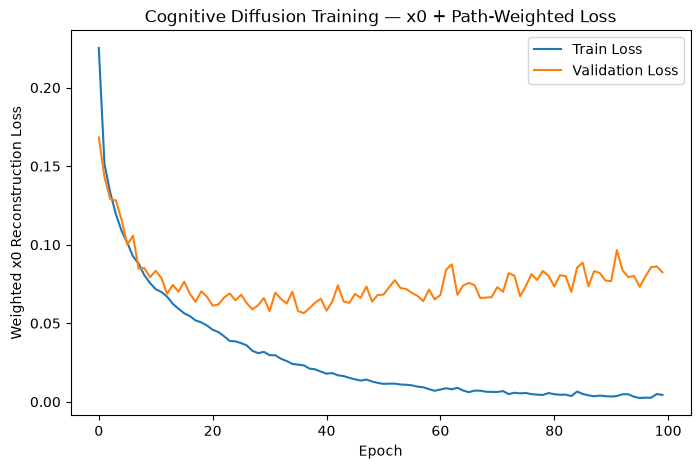

In [39]:
import matplotlib.pyplot as plt

plt.figure(
    figsize=(8, 5)
)

plt.plot(
    train_losses,
    label="Train Loss"
)

plt.plot(
    val_losses,
    label="Validation Loss"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Weighted x0 Reconstruction Loss"
)

plt.title(
    "Cognitive Diffusion Training — x0 + Path-Weighted Loss"
)

plt.legend()

plt.show()

## Reverse diffusion / inference

In [40]:
@torch.no_grad()
def p_sample(
    model,
    diffusion,
    x,
    map_latent,
    timestep,
    timestep_index
):

    # ========================================
    # Predict clean x0
    # ========================================

    predicted_x0 = model.predict_x0(
        x,
        map_latent,
        timestep
    )

    # Keep prediction in training data range
    predicted_x0 = torch.clamp(
        predicted_x0,
        -1.0,
        1.0
    )

    # ========================================
    # Extract diffusion coefficients
    # ========================================

    beta_t = extract(
        diffusion.betas,
        timestep,
        x.shape
    )

    alpha_t = extract(
        diffusion.alphas,
        timestep,
        x.shape
    )

    alpha_cumprod_t = extract(
        diffusion.alpha_cumprod,
        timestep,
        x.shape
    )

    alpha_cumprod_prev_t = extract(
        diffusion.alpha_cumprod_prev,
        timestep,
        x.shape
    )

    # ========================================
    # Posterior mean:
    #
    # q(x_{t-1} | x_t, x0)
    # ========================================

    coefficient_x0 = (
        torch.sqrt(
            alpha_cumprod_prev_t
        )
        *
        beta_t
        /
        (
            1.0
            -
            alpha_cumprod_t
        )
    )

    coefficient_xt = (
        torch.sqrt(
            alpha_t
        )
        *
        (
            1.0
            -
            alpha_cumprod_prev_t
        )
        /
        (
            1.0
            -
            alpha_cumprod_t
        )
    )

    model_mean = (
        coefficient_x0
        *
        predicted_x0
        +
        coefficient_xt
        *
        x
    )

    # ========================================
    # Final step: no additional noise
    # ========================================

    if timestep_index == 0:
        return model_mean

    # ========================================
    # Posterior variance
    # ========================================

    posterior_variance_t = extract(
        diffusion.posterior_variance,
        timestep,
        x.shape
    )

    noise = torch.randn_like(
        x
    )

    return (
        model_mean
        +
        torch.sqrt(
            posterior_variance_t
        )
        *
        noise
    )

In [41]:
@torch.no_grad()
def sample_path(
    model,
    diffusion,
    grid_map,
    device
):

    model.eval()

    grid_map = grid_map.to(
        device
    )

    if grid_map.dim() == 3:
        grid_map = grid_map.unsqueeze(0)

    batch_size = grid_map.shape[0]

    # ========================================
    # Encode map ONCE
    # ========================================

    map_latent = model.encode_map(
        grid_map
    )

    # ========================================
    # Start from pure Gaussian noise
    # ========================================

    x = torch.randn(
        batch_size,
        1,
        IMAGE_SIZE,
        IMAGE_SIZE,
        device=device
    )

    # ========================================
    # Reverse diffusion
    # ========================================

    for i in tqdm(
        reversed(
            range(
                diffusion.timesteps
            )
        ),
        total=diffusion.timesteps,
        desc="Sampling"
    ):

        timestep = torch.full(
            (batch_size,),
            i,
            device=device,
            dtype=torch.long
        )

        x = p_sample(
            model,
            diffusion,
            x,
            map_latent,
            timestep,
            i
        )

    # ========================================
    # [-1,1] → [0,1]
    # ========================================

    x = (
        x + 1.0
    ) / 2.0

    x = torch.clamp(
        x,
        0.0,
        1.0
    )

    return x

## Load best model

In [42]:
checkpoint = torch.load(
    os.path.join(
        CHECKPOINT_DIR,
        "best.pt"
    ),
    map_location=DEVICE
)

model.load_state_dict(
    checkpoint[
        "model_state_dict"
    ]
)

model.eval()

print(
    "Loaded epoch:",
    checkpoint["epoch"]
)

print(
    "Validation loss:",
    checkpoint["val_loss"]
)

Loaded epoch: 37
Validation loss: 0.05644243216374889


/tmp/ipykernel_12623/221025179.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(


## Predict on validation sample

In [43]:
import matplotlib.pyplot as plt
import numpy as np


@torch.no_grad()
def visualize_samples(
    model,
    diffusion,
    dataset,
    indices,
    device
):
    """
    Visualize multiple validation samples.

    Each row:
        Input Map | A* Ground Truth | Diffusion Prediction
    """

    num_samples = len(indices)

    fig, axes = plt.subplots(
        num_samples,
        3,
        figsize=(15, 5 * num_samples)
    )

    # If only one sample is requested,
    # make axes 2D for consistent indexing
    if num_samples == 1:
        axes = np.expand_dims(axes, axis=0)

    for row, idx in enumerate(indices):

        # ========================================
        # Load sample
        # ========================================

        sample = dataset[idx]

        grid_map = sample["map"]
        ground_truth = sample["path"]

        # [-1, 1] -> [0, 1]
        ground_truth_01 = (
            ground_truth + 1.0
        ) / 2.0

        # ========================================
        # Diffusion inference
        # ========================================

        predicted_path = sample_path(
            model,
            diffusion,
            grid_map,
            device
        )

        # ========================================
        # Extract map channels
        # ========================================

        obstacle = grid_map[0].cpu().numpy()
        start_map = grid_map[1].cpu().numpy()
        goal_map = grid_map[2].cpu().numpy()

        gt = ground_truth_01[0].cpu().numpy()

        pred = (
            predicted_path[0, 0]
            .cpu()
            .numpy()
        )

        binary_pred = pred > 0.5

        # ========================================
        # Start / goal coordinates
        # ========================================

        start_y, start_x = np.where(
            start_map > 0.5
        )

        goal_y, goal_x = np.where(
            goal_map > 0.5
        )

        # ========================================
        # Ground-truth coordinates
        # ========================================

        gt_y, gt_x = np.where(
            gt > 0.5
        )

        # ========================================
        # Prediction coordinates
        # ========================================

        pred_y, pred_x = np.where(
            binary_pred
        )

        # ========================================
        # Column 1: Input Map
        # ========================================

        ax = axes[row, 0]

        ax.imshow(
            obstacle,
            cmap="gray_r"
        )

        ax.scatter(
            start_x,
            start_y,
            marker="o",
            s=80,
            label="Start"
        )

        ax.scatter(
            goal_x,
            goal_y,
            marker="*",
            s=120,
            label="Goal"
        )

        ax.set_title(
            f"Sample {idx} — Input Map"
        )

        ax.axis("off")

        if row == 0:
            ax.legend()

        # ========================================
        # Column 2: A* Ground Truth
        # ========================================

        ax = axes[row, 1]

        ax.imshow(
            obstacle,
            cmap="gray_r"
        )

        ax.scatter(
            gt_x,
            gt_y,
            s=8
        )

        ax.scatter(
            start_x,
            start_y,
            marker="o",
            s=80
        )

        ax.scatter(
            goal_x,
            goal_y,
            marker="*",
            s=120
        )

        ax.set_title(
            f"Sample {idx} — A* Ground Truth"
        )

        ax.axis("off")

        # ========================================
        # Column 3: Diffusion Prediction
        # ========================================

        ax = axes[row, 2]

        ax.imshow(
            obstacle,
            cmap="gray_r"
        )

        ax.scatter(
            pred_x,
            pred_y,
            s=8
        )

        ax.scatter(
            start_x,
            start_y,
            marker="o",
            s=80
        )

        ax.scatter(
            goal_x,
            goal_y,
            marker="*",
            s=120
        )

        ax.set_title(
            f"Sample {idx} — Diffusion Prediction"
        )

        ax.axis("off")

    plt.tight_layout()
    plt.show()

Sampling:   0%|          | 0/1000 [00:00<?, ?it/s]

Sampling:   0%|          | 0/1000 [00:00<?, ?it/s]

Sampling:   0%|          | 0/1000 [00:00<?, ?it/s]

Sampling:   0%|          | 0/1000 [00:00<?, ?it/s]

Sampling:   0%|          | 0/1000 [00:00<?, ?it/s]

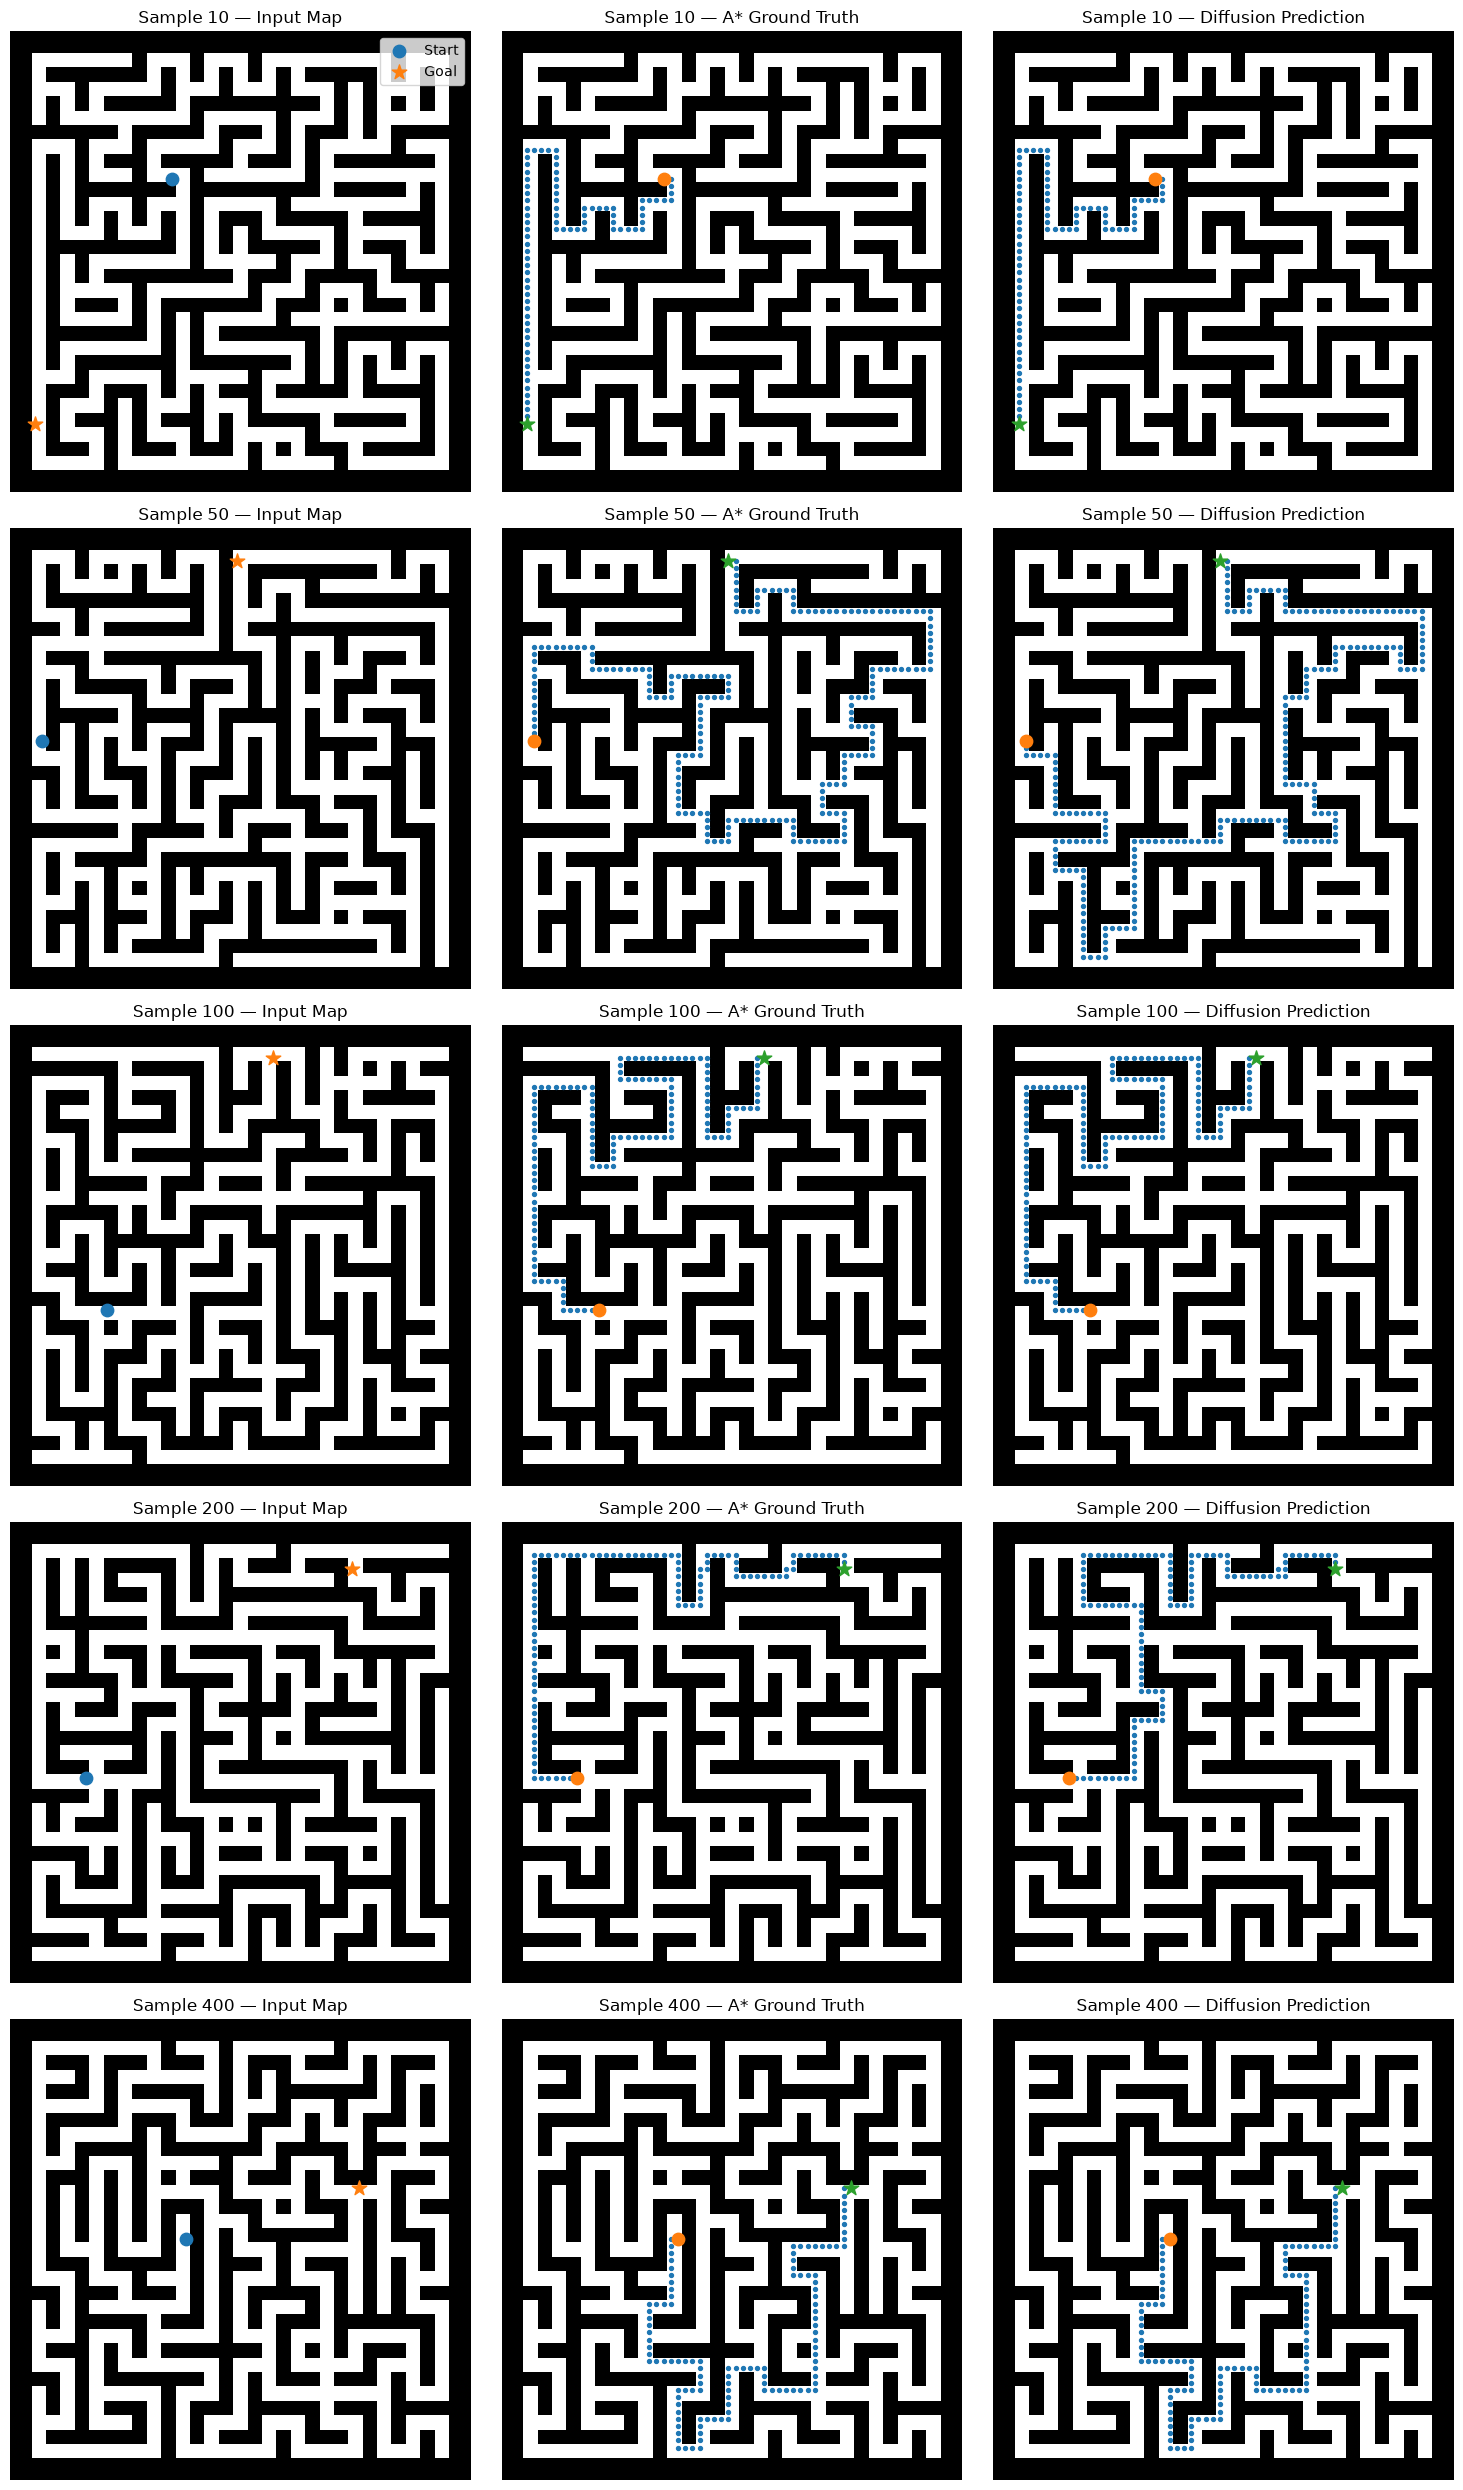

In [44]:
visualize_samples(
    model=model,
    diffusion=diffusion,
    dataset=val_dataset,
    indices=[10, 50, 100, 200, 400],
    device=DEVICE
)

Testing samples: [521, 737, 740, 660, 411, 678, 626, 513, 859, 136]


Sampling:   0%|          | 0/1000 [00:00<?, ?it/s]

Sampling:   0%|          | 0/1000 [00:00<?, ?it/s]

Sampling:   0%|          | 0/1000 [00:00<?, ?it/s]

Sampling:   0%|          | 0/1000 [00:00<?, ?it/s]

...

Sampling:   0%|          | 0/1000 [00:00<?, ?it/s]

Sampling:   0%|          | 0/1000 [00:00<?, ?it/s]

Sampling:   0%|          | 0/1000 [00:00<?, ?it/s]

Sampling:   0%|          | 0/1000 [00:00<?, ?it/s]

Sampling:   0%|          | 0/1000 [00:00<?, ?it/s]

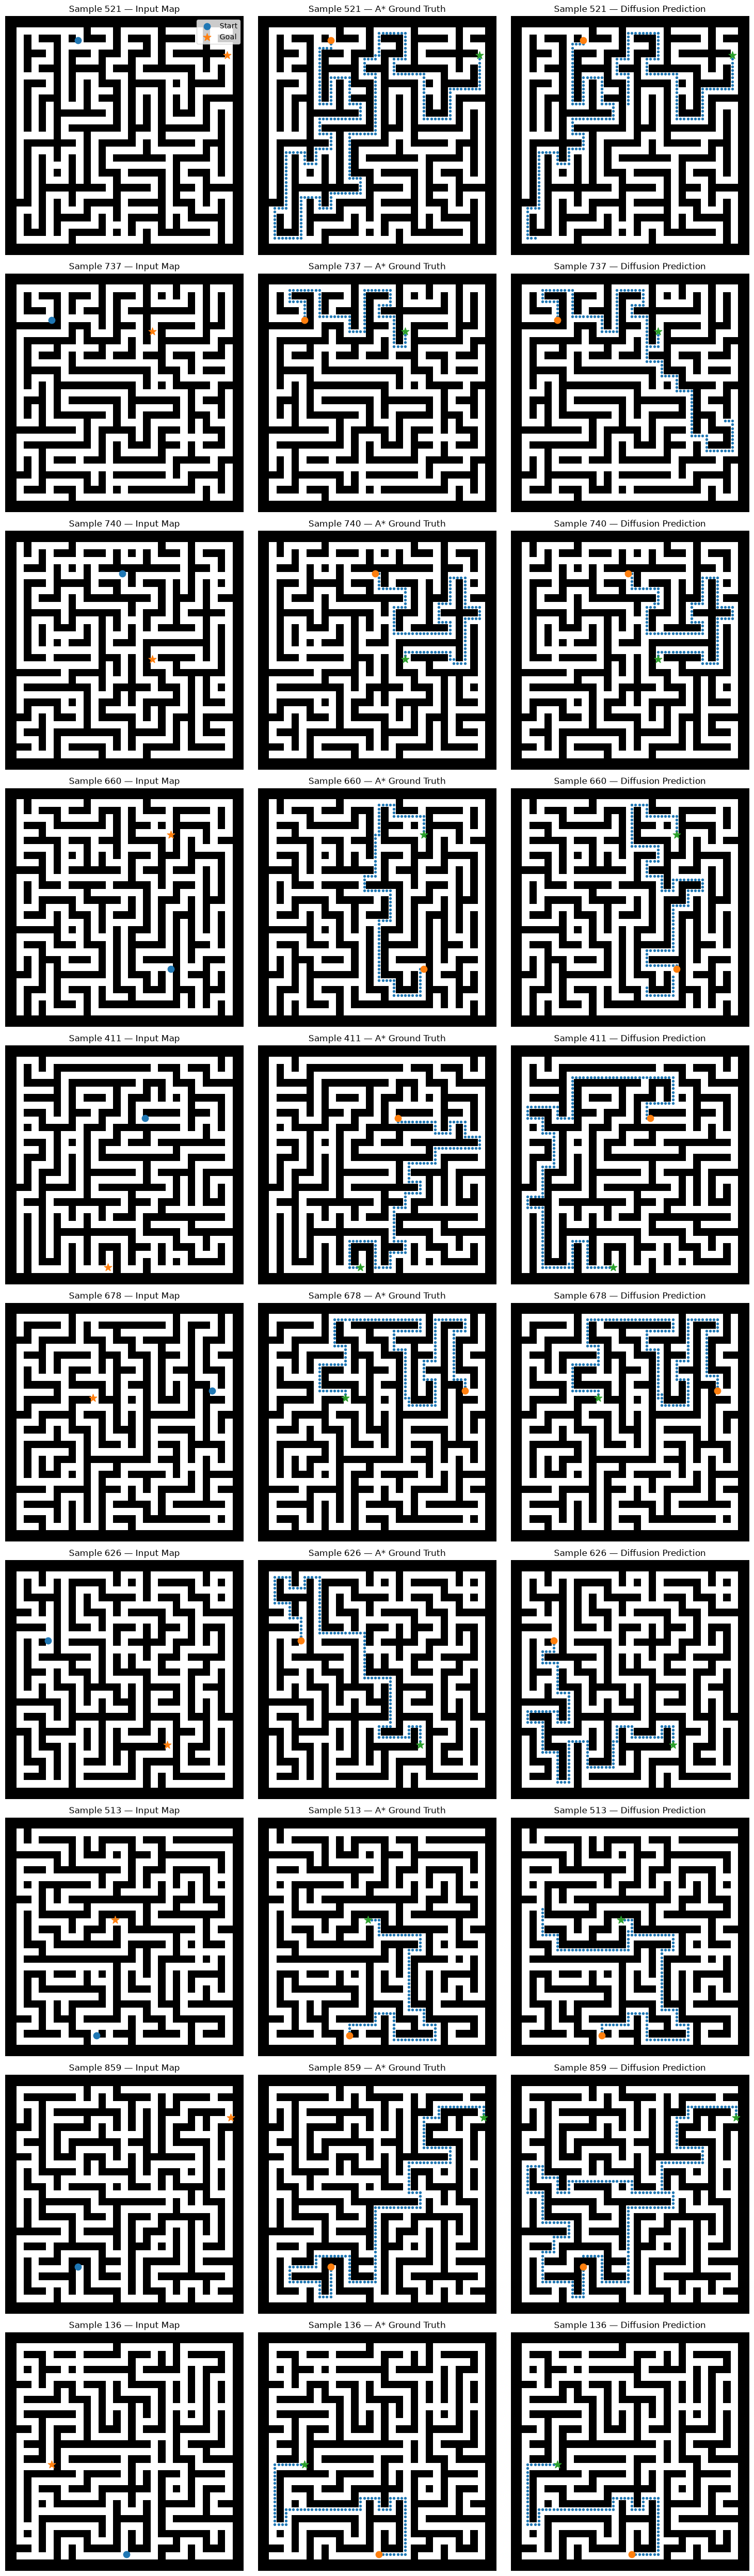

In [45]:
indices = np.random.choice(
    len(val_dataset),
    size=10,
    replace=False
).tolist()

print("Testing samples:", indices)

visualize_samples(
    model=model,
    diffusion=diffusion,
    dataset=val_dataset,
    indices=indices,
    device=DEVICE
)

## Validation evaluator

In [46]:
import numpy as np
import torch
from collections import deque
from tqdm.auto import tqdm

In [47]:
def check_4neighbor_connection(
    binary_path,
    start,
    goal
):
    """
    binary_path: numpy array [H, W], bool
    start: (y, x)
    goal: (y, x)

    Returns:
        True if goal is reachable from start
        using only 4-neighbor path pixels.
    """

    H, W = binary_path.shape

    sy, sx = start
    gy, gx = goal

    # start / goal must both belong to path
    if not binary_path[sy, sx]:
        return False

    if not binary_path[gy, gx]:
        return False

    visited = np.zeros(
        (H, W),
        dtype=bool
    )

    queue = deque()

    queue.append(
        (sy, sx)
    )

    visited[sy, sx] = True

    directions = [
        (-1, 0),   # up
        (1, 0),    # down
        (0, -1),   # left
        (0, 1)     # right
    ]

    while queue:

        y, x = queue.popleft()

        # reached goal
        if (y, x) == (gy, gx):
            return True

        for dy, dx in directions:

            ny = y + dy
            nx = x + dx

            if (
                0 <= ny < H
                and
                0 <= nx < W
            ):

                if (
                    binary_path[ny, nx]
                    and
                    not visited[ny, nx]
                ):

                    visited[ny, nx] = True

                    queue.append(
                        (ny, nx)
                    )

    return False

In [48]:
@torch.no_grad()
def evaluate_single_sample(
    model,
    diffusion,
    sample,
    device,
    threshold=0.5
):
    """
    Evaluate one generated path.

    Returns dictionary with:
        start_in_path
        goal_in_path
        collision_free
        connected
    """

    grid_map = sample["map"]

    # ========================================
    # Generate predicted path
    # ========================================

    predicted_path = sample_path(
        model,
        diffusion,
        grid_map,
        device
    )

    pred = (
        predicted_path[0, 0]
        .cpu()
        .numpy()
    )

    binary_path = (
        pred > threshold
    )

    # ========================================
    # Extract map channels
    # ========================================

    obstacle = (
        grid_map[0]
        .cpu()
        .numpy()
        > 0.5
    )

    start_map = (
        grid_map[1]
        .cpu()
        .numpy()
        > 0.5
    )

    goal_map = (
        grid_map[2]
        .cpu()
        .numpy()
        > 0.5
    )

    # ========================================
    # Find start / goal
    # ========================================

    start_y, start_x = np.where(
        start_map
    )

    goal_y, goal_x = np.where(
        goal_map
    )

    if len(start_y) != 1:
        raise ValueError(
            "Expected exactly one start cell."
        )

    if len(goal_y) != 1:
        raise ValueError(
            "Expected exactly one goal cell."
        )

    start = (
        int(start_y[0]),
        int(start_x[0])
    )

    goal = (
        int(goal_y[0]),
        int(goal_x[0])
    )

    # ========================================
    # Metric 1:
    # Start included?
    # ========================================

    sy, sx = start

    start_in_path = bool(
        binary_path[sy, sx]
    )

    # ========================================
    # Metric 2:
    # Goal included?
    # ========================================

    gy, gx = goal

    goal_in_path = bool(
        binary_path[gy, gx]
    )

    # ========================================
    # Metric 3:
    # Collision free?
    # ========================================

    collision_mask = (
        binary_path
        &
        obstacle
    )

    collision_count = int(
        collision_mask.sum()
    )

    collision_free = (
        collision_count == 0
    )

    # ========================================
    # Metric 4:
    # Connected start -> goal?
    # ========================================

    connected = (
        check_4neighbor_connection(
            binary_path,
            start,
            goal
        )
    )

    return {
        "start_in_path":
            start_in_path,

        "goal_in_path":
            goal_in_path,

        "collision_free":
            collision_free,

        "collision_count":
            collision_count,

        "connected":
            connected
    }

In [49]:
@torch.no_grad()
def evaluate_validation_set(
    model,
    diffusion,
    dataset,
    device,
    num_samples=1000,
    threshold=0.5
):
    """
    Evaluate multiple validation samples.
    """

    model.eval()

    num_samples = min(
        num_samples,
        len(dataset)
    )

    results = []

    for idx in tqdm(
        range(num_samples),
        desc="Evaluating"
    ):

        sample = dataset[idx]

        result = evaluate_single_sample(
            model=model,
            diffusion=diffusion,
            sample=sample,
            device=device,
            threshold=threshold
        )

        result["index"] = idx

        results.append(
            result
        )

    return results

In [50]:
results = evaluate_validation_set(
    model=model,
    diffusion=diffusion,
    dataset=val_dataset,
    device=DEVICE,
    num_samples=1000,
    threshold=0.5
)

Evaluating:   0%|          | 0/1000 [00:00<?, ?it/s]

Sampling:   0%|          | 0/1000 [00:00<?, ?it/s]

Sampling:   0%|          | 0/1000 [00:00<?, ?it/s]

Sampling:   0%|          | 0/1000 [00:00<?, ?it/s]

Sampling:   0%|          | 0/1000 [00:00<?, ?it/s]

...

Sampling:   0%|          | 0/1000 [00:00<?, ?it/s]

Sampling:   0%|          | 0/1000 [00:00<?, ?it/s]

Sampling:   0%|          | 0/1000 [00:00<?, ?it/s]

Sampling:   0%|          | 0/1000 [00:00<?, ?it/s]

Sampling:   0%|          | 0/1000 [00:00<?, ?it/s]

In [51]:
def summarize_results(
    results
):

    total = len(results)

    start_rate = sum(
        r["start_in_path"]
        for r in results
    ) / total

    goal_rate = sum(
        r["goal_in_path"]
        for r in results
    ) / total

    collision_free_rate = sum(
        r["collision_free"]
        for r in results
    ) / total

    connected_rate = sum(
        r["connected"]
        for r in results
    ) / total

    avg_collisions = np.mean(
        [
            r["collision_count"]
            for r in results
        ]
    )

    print(
        f"Samples evaluated: {total}"
    )

    print(
        f"Start included:      "
        f"{start_rate * 100:.2f}%"
    )

    print(
        f"Goal included:       "
        f"{goal_rate * 100:.2f}%"
    )

    print(
        f"Collision-free:      "
        f"{collision_free_rate * 100:.2f}%"
    )

    print(
        f"Connected S -> G:    "
        f"{connected_rate * 100:.2f}%"
    )

    print(
        f"Average collisions:  "
        f"{avg_collisions:.2f}"
    )

In [52]:
summarize_results(
    results
)

Samples evaluated: 1000
Start included:      100.00%
Goal included:       100.00%
Collision-free:      99.30%
Connected S -> G:    83.60%
Average collisions:  0.01


In [53]:
def compute_success_rate(
    results
):

    successes = []

    for r in results:

        success = (
            r["start_in_path"]
            and
            r["goal_in_path"]
            and
            r["collision_free"]
            and
            r["connected"]
        )

        successes.append(
            success
        )

    success_rate = (
        sum(successes)
        /
        len(successes)
    )

    print(
        f"Valid Path Success:  "
        f"{success_rate * 100:.2f}%"
    )

    return success_rate

In [54]:
success_rate = compute_success_rate(
    results
)

Valid Path Success:  83.30%
